# ElbowSig tutorial

This notebook demonstrates the use of `ElbowSig`.

### Preliminaries

Calling necessary function

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "2"

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

import ElbowSig as ElbowSig


## Example

Generating synthetic data:

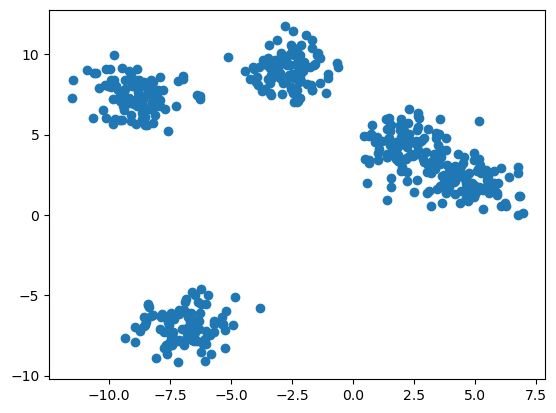

In [3]:
from sklearn.datasets import make_blobs

# Synthetic data
X, y = make_blobs(n_samples=500, centers=5, cluster_std=1, random_state=42)

plt.plot(X[:, 0], X[:, 1], 'o')

### Agglomerative

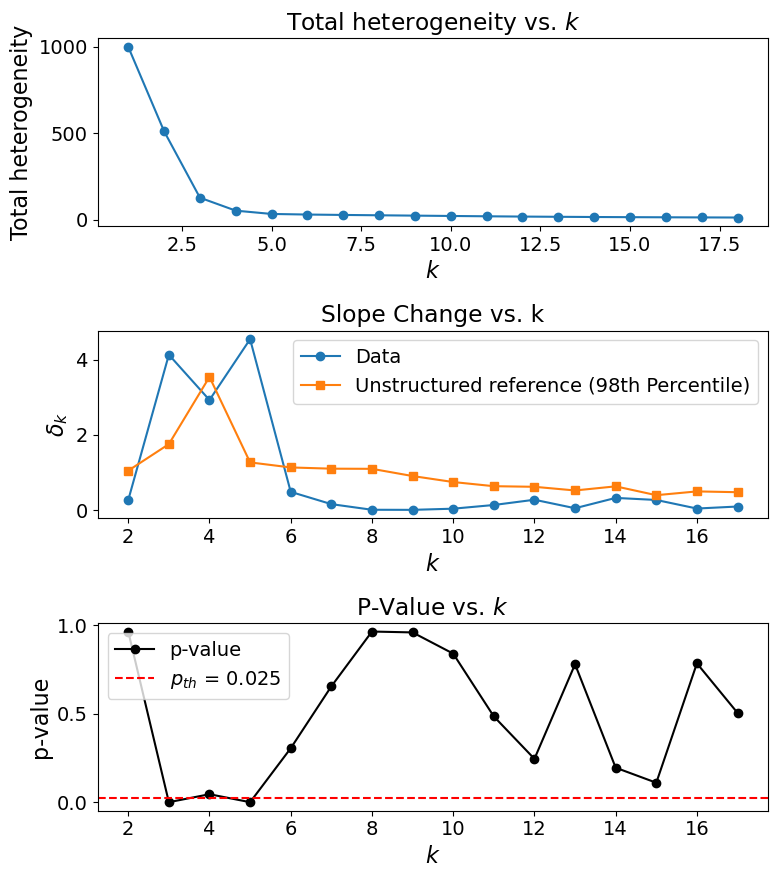

p-values:  [0.965 0.    0.045 0.    0.305 0.655 0.965 0.96  0.84  0.485 0.245 0.78
 0.195 0.11  0.785 0.505]


In [5]:
#k_values0, slope_change0, mean_slope_change, sd_slope_change, percentile, p_values, slope_change_distribution 
out = ElbowSig.Elbow_significance_general(
    X=X,
    kmax=18,
    nr=200,
    alpha=0.05,
    plotYN='y',
    random_state=42,
    heterogeneity_func=ElbowSig.Agglomerative_Heterogeneity,
    pars=['euclidean', 'ward']
)

#Agglomerative_Heterogeneity(X, k, random_state=42, pars=['euclidean', 'ward'])


print('p-values: ', out['p_values'])

The plot presented above can be made a posteriori using `plot_Elbow_significance_general_results`

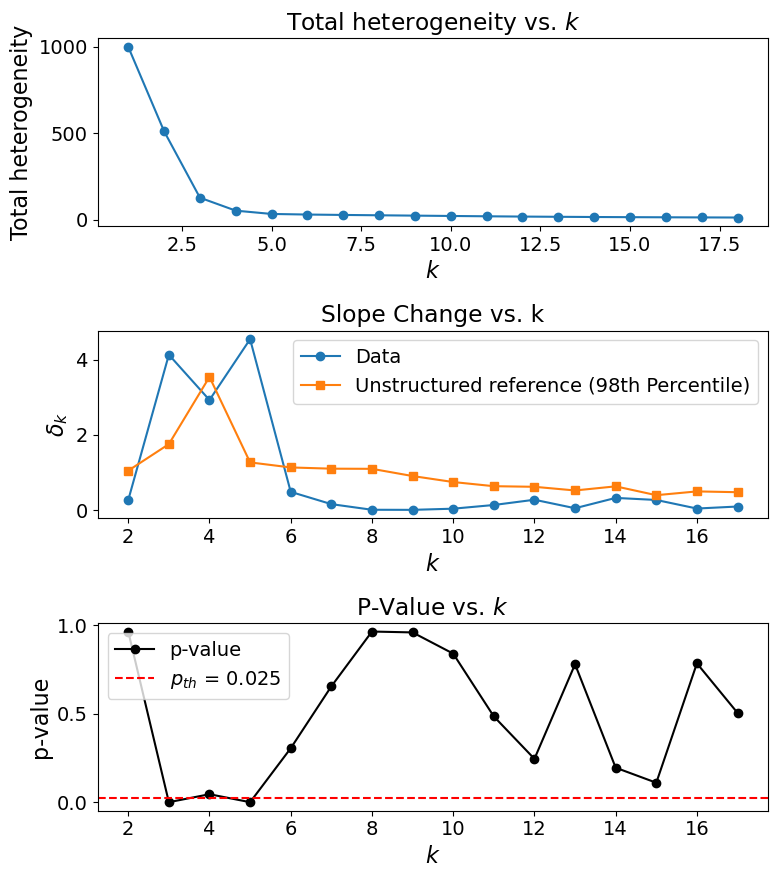

In [6]:
ElbowSig.plot_Elbow_significance_general_results(out)

Graphical comparison of the observed $\delta_k$ and the distribution of $\delta_k$ for random unstructured reference data:

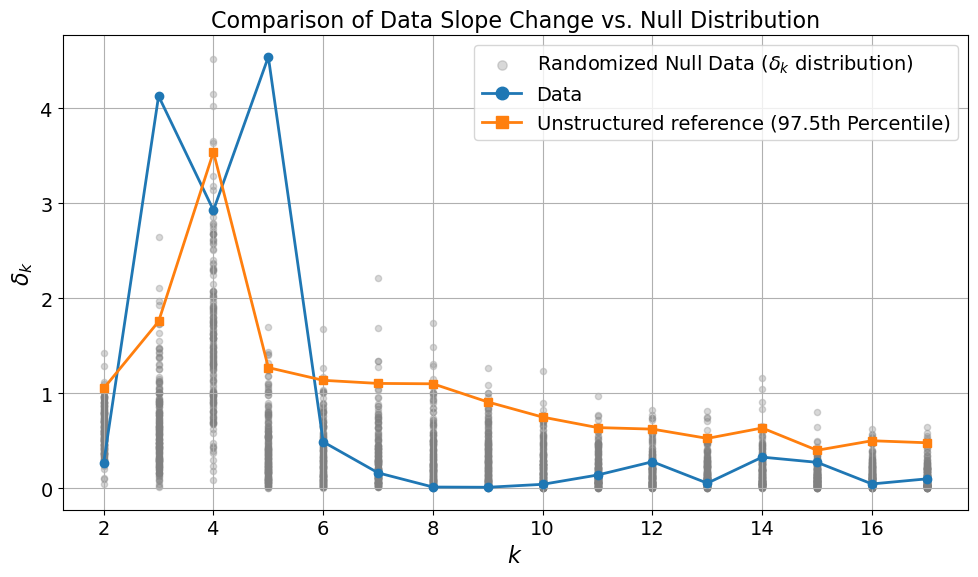

In [7]:
ElbowSig.compare_slope_changes_scatter_results(out)

#### Visualizing the clusters

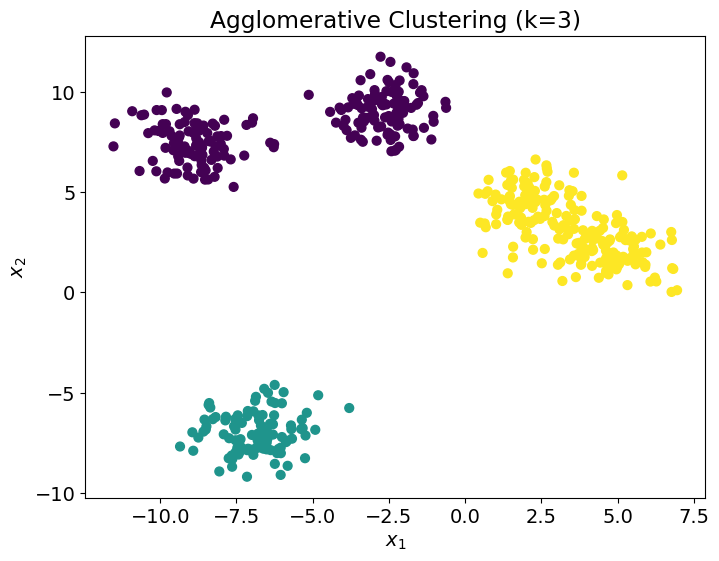

In [8]:
k = 3
ElbowSig.visualize_agglomerative_clustering(X, k)

#### Exploring the output of the function `Elbow_significance_general`

Information in the `out` object

In [9]:
out.keys()

dict_keys(['k_values', 'hetero_k_stat', 'slope_change', 'percentile', 'p_values', 'k_optimal', 'slope_change_distribution', 'pv_thres_list', 'p_sig_thres'])

p-values

In [10]:
out['p_values']

array([0.965, 0.   , 0.045, 0.   , 0.305, 0.655, 0.965, 0.96 , 0.84 ,
       0.485, 0.245, 0.78 , 0.195, 0.11 , 0.785, 0.505])

Optimal k

In [11]:
out['k_optimal']

[3, 5]

Threshold $p_{th}$ for the p-value ensuring that a true null hypothesis (i.e. random unstructured data) would only be rejected with probability $\alpha$ (set in `Elbow_significance_general`):

In [12]:
out['p_sig_thres']

0.02475

Values of $k$ for which $\text{p-value}<p_{th}$:

In [13]:
out['k_values'][out['p_values']<out['p_sig_thres']]

array([3, 5])

#### Gap statistic on these data using agglomerative clustering

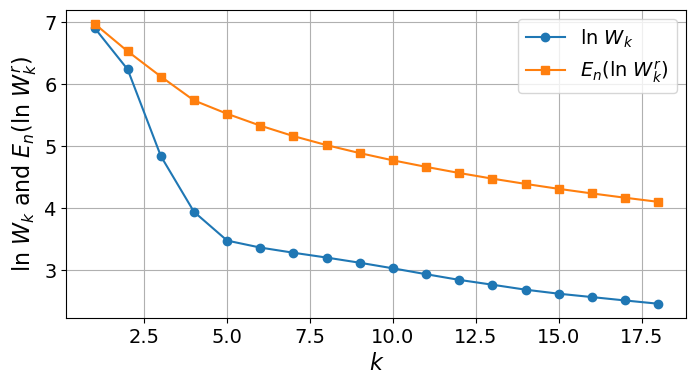

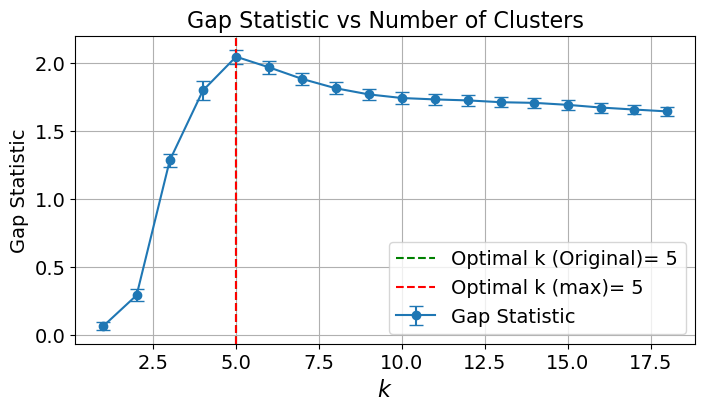

In [14]:
wcss_values, gap_values, sk_values, optimal_k_tibshirani, optimal_k_max_gap = ElbowSig.compute_gap_statistic(X, 
max_k=18, 
n_refs=200, 
cluster_method="Agglomerate",
plot=True)

### k-means

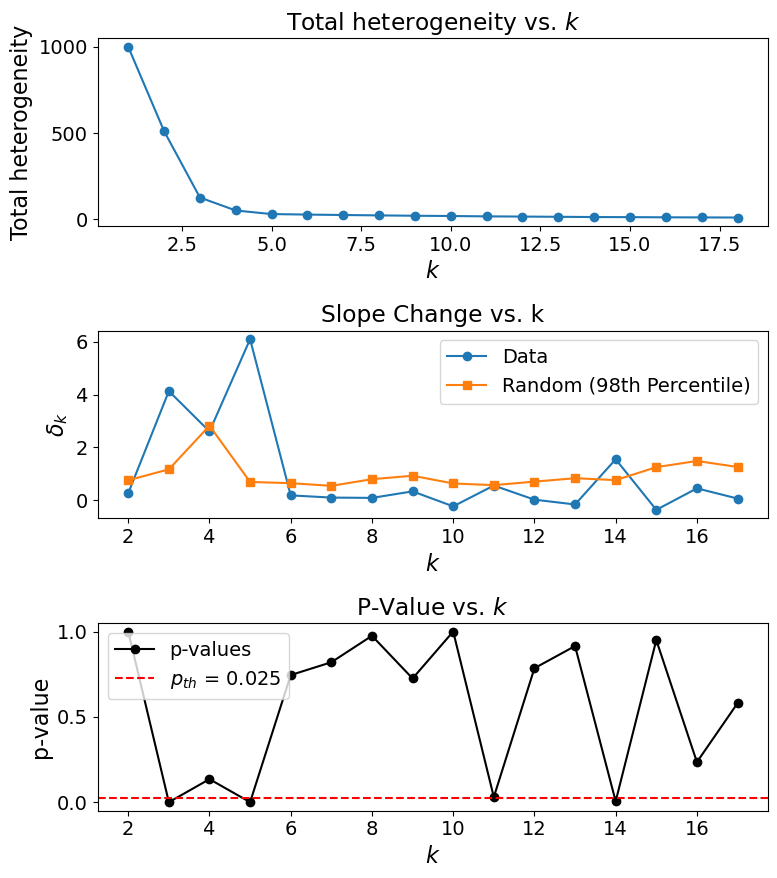

p-values:  [1.    0.    0.135 0.    0.745 0.82  0.975 0.725 1.    0.03  0.785 0.915
 0.005 0.95  0.235 0.58 ]


In [21]:
#k_values0, slope_change0, mean_slope_change, sd_slope_change, percentile, p_values, slope_change_distribution 
out = ElbowSig.Elbow_significance_general(
    X=X,
    kmax=18,
    nr=200,
    alpha=0.05,
    plotYN='y',
    random_state=42,
    heterogeneity_func=ElbowSig.Kmeans_Heterogeneity,
    pars=[10]
)

#Kmeans_Heterogeneity(X, k, random_state=42, pars=[10])

print('p-values: ', out['p_values'])

### Fuzzy c-means

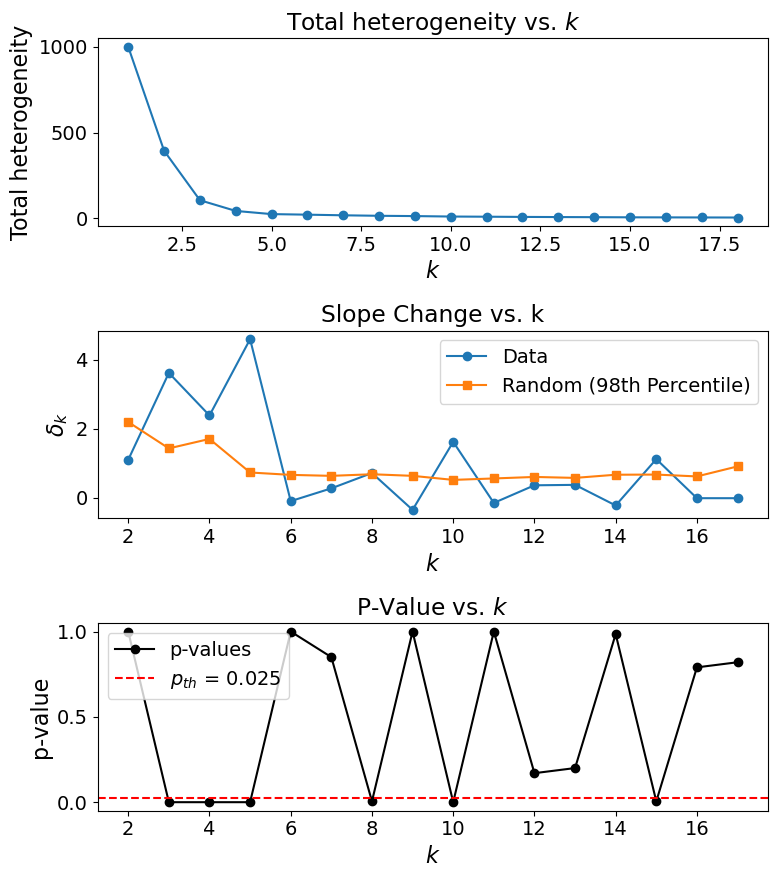

p-values:  [1.    0.    0.    0.    1.    0.85  0.005 1.    0.    1.    0.17  0.2
 0.985 0.005 0.79  0.82 ]


In [22]:
out = ElbowSig.Elbow_significance_general(
    X=X,
    kmax=18,
    nr=200,
    alpha=0.05,
    plotYN='y',
    random_state=42,
    heterogeneity_func=ElbowSig.FCM_Heterogeneity,
    pars=[2, 0.005, 1000]
)

#X, kmax=10, nr=100, alpha=0.05, plotYN=True, random_state=42, heterogeneity_func=FCM_Heterogeneity,pars=[2, 0.005, 1000]

print('p-values: ', out['p_values'])

### Gaussian Mixture Model

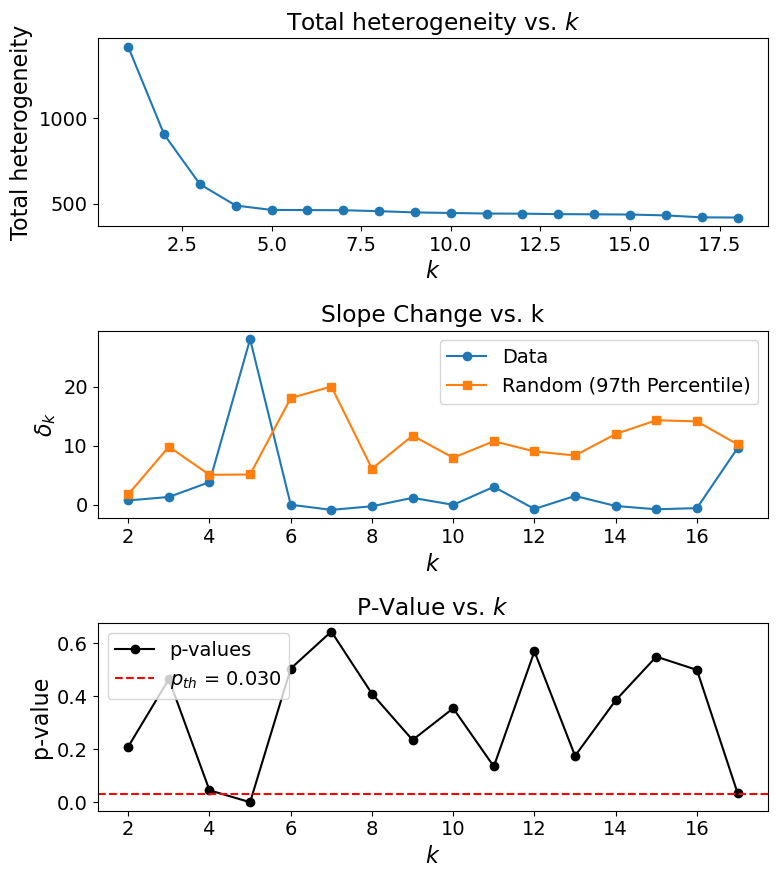

p-values:  [0.21  0.465 0.045 0.    0.505 0.645 0.41  0.235 0.355 0.135 0.57  0.175
 0.385 0.55  0.5   0.035]


In [23]:
#k_values0, slope_change0, mean_slope_change, sd_slope_change, percentile, p_values, slope_change_distribution 
out = ElbowSig.Elbow_significance_general(
    X=X,
    kmax=18,
    nr=200,
    alpha=0.05,
    plotYN='y',
    random_state=4,
    heterogeneity_func=ElbowSig.GMM_Heterogeneity,
    pars=['full']
)

#GMM_Heterogeneity(X, k, random_state=42, pars=['full'])

print('p-values: ', out['p_values'])